In [1]:
import gtsam
import numpy as np
import matplotlib.pyplot as plt

In [2]:
graph = gtsam.NonlinearFactorGraph()
poses = gtsam.Values()

PRIOR_NOISE = gtsam.noiseModel.Diagonal.Sigmas(2 * np.array([1.0, 1.0, 1.0]))

pose = gtsam.Pose2(np.zeros(3))
graph.add(gtsam.PriorFactorPose2(0, pose, PRIOR_NOISE))
poses.insert(0, pose)

optimizer = gtsam.LevenbergMarquardtOptimizer(graph, poses)
poses = optimizer.optimize()

graph.linearize(poses).hessian()[0]


array([[0.25, 0.  , 0.  ],
       [0.  , 0.25, 0.  ],
       [0.  , 0.  , 0.25]])

Values with 2 values:
Value 0: (gtsam::Pose2)
(0, 0, 0)

Value 1: (gtsam::Pose2)
(1, 0, 0)




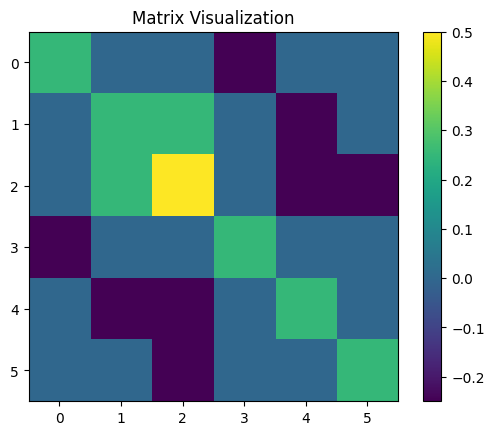

array([[ 0.25,  0.  ,  0.  , -0.25,  0.  ,  0.  ],
       [ 0.  ,  0.25,  0.25,  0.  , -0.25,  0.  ],
       [ 0.  ,  0.25,  0.5 ,  0.  , -0.25, -0.25],
       [-0.25,  0.  ,  0.  ,  0.25,  0.  ,  0.  ],
       [ 0.  , -0.25, -0.25,  0.  ,  0.25,  0.  ],
       [ 0.  ,  0.  , -0.25,  0.  ,  0.  ,  0.25]])

In [3]:
graph = gtsam.NonlinearFactorGraph()
poses = gtsam.Values()

PRIOR_NOISE = gtsam.noiseModel.Diagonal.Sigmas(1 * np.array([1.0, 1.0, 1.0]))
ODOMETRY_NOISE = gtsam.noiseModel.Diagonal.Sigmas(2 * np.array([1.0, 1.0, 1.0]))

pose = gtsam.Pose2(np.zeros(3))
# graph.add(gtsam.PriorFactorPose2(0, pose, PRIOR_NOISE))
poses.insert(0, pose)

graph.add(gtsam.BetweenFactorPose2(0, 1, gtsam.Pose2(1, 0, 0), ODOMETRY_NOISE))
poses.insert(1, gtsam.Pose2(1, 0, 0))

# graph.add(gtsam.BetweenFactorPose2(0, 2, gtsam.Pose2(0, 1, 0), ODOMETRY_NOISE))
# poses.insert(2, gtsam.Pose2())
#
# graph.add(gtsam.BetweenFactorPose2(0, 3, gtsam.Pose2(-1, 0, 0), ODOMETRY_NOISE))
# poses.insert(3, gtsam.Pose2())

optimizer = gtsam.LevenbergMarquardtOptimizer(graph, poses)
poses = optimizer.optimize()

print(poses)

H = graph.linearize(poses).hessian()[0]

plt.imshow(H, cmap='viridis', interpolation='nearest')
plt.colorbar()  # Add a color bar to the side
plt.title('Matrix Visualization')
plt.show()

H

Values with 4 values:
Value 0: (gtsam::Pose2)
(-2.39889e-10, -6.79763e-10, 5.98998e-11)

Value 1: (gtsam::Pose2)
(1, -6.12741e-11, 2.93855e-09)

Value 2: (gtsam::Pose2)
(1, 1, 4.77774e-09)

Value 3: (gtsam::Pose2)
(-2.4362e-08, 1, 5.09755e-09)




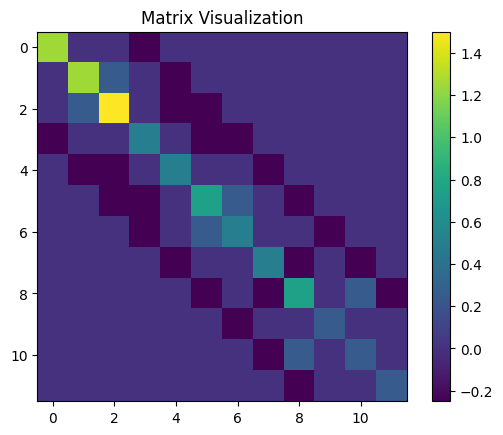

3.814697265625008e-06

In [4]:
graph = gtsam.NonlinearFactorGraph()
poses = gtsam.Values()

PRIOR_NOISE = gtsam.noiseModel.Diagonal.Sigmas(1 * np.array([1.0, 1.0, 1.0]))
ODOMETRY_NOISE = gtsam.noiseModel.Diagonal.Sigmas(2 * np.array([1.0, 1.0, 1.0]))

pose = gtsam.Pose2(np.zeros(3))
graph.add(gtsam.PriorFactorPose2(0, pose, PRIOR_NOISE))
poses.insert(0, pose)

graph.add(gtsam.BetweenFactorPose2(0, 1, gtsam.Pose2(1, 0, 0), ODOMETRY_NOISE))
poses.insert(1, gtsam.Pose2(1, 0, 0))

graph.add(gtsam.BetweenFactorPose2(1, 2, gtsam.Pose2(0, 1, 0), ODOMETRY_NOISE))
poses.insert(2, gtsam.Pose2())

graph.add(gtsam.BetweenFactorPose2(2, 3, gtsam.Pose2(-1, 0, 0), ODOMETRY_NOISE))
poses.insert(3, gtsam.Pose2())

# graph.add(gtsam.BetweenFactorPose2(3, 0, gtsam.Pose2(0, -1, 0), ODOMETRY_NOISE))

optimizer = gtsam.LevenbergMarquardtOptimizer(graph, poses)
poses = optimizer.optimize()

print(poses)

H = graph.linearize(poses).hessian()[0]

plt.imshow(H, cmap='viridis', interpolation='nearest')
plt.colorbar()  # Add a color bar to the side
plt.title('Matrix Visualization')
plt.show()

H

np.linalg.det(H)

Values with 4 values:
Value 0: (gtsam::Pose2)
(-1.19985e-10, -2.29448e-10, -1.68411e-11)

Value 1: (gtsam::Pose2)
(1, -3.19626e-10, 6.72993e-11)

Value 2: (gtsam::Pose2)
(1, 1, 1.57487e-10)

Value 3: (gtsam::Pose2)
(-8.05617e-10, 1, 2.83844e-10)




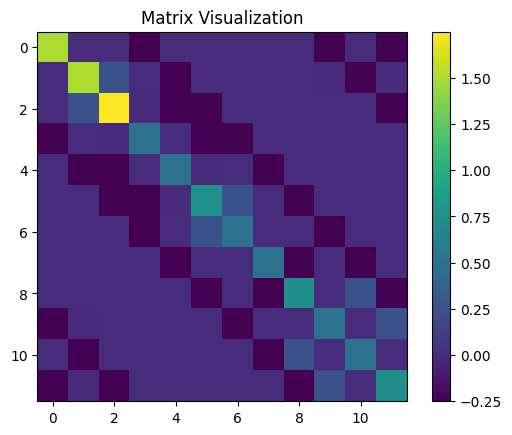

0.00038146972646059914

In [5]:
graph = gtsam.NonlinearFactorGraph()
poses = gtsam.Values()

PRIOR_NOISE = gtsam.noiseModel.Diagonal.Sigmas(1 * np.array([1.0, 1.0, 1.0]))
ODOMETRY_NOISE = gtsam.noiseModel.Diagonal.Sigmas(2 * np.array([1.0, 1.0, 1.0]))

pose = gtsam.Pose2(np.zeros(3))
graph.add(gtsam.PriorFactorPose2(0, pose, PRIOR_NOISE))
poses.insert(0, pose)

graph.add(gtsam.BetweenFactorPose2(0, 1, gtsam.Pose2(1, 0, 0), ODOMETRY_NOISE))
poses.insert(1, gtsam.Pose2(1, 0, 0))

graph.add(gtsam.BetweenFactorPose2(1, 2, gtsam.Pose2(0, 1, 0), ODOMETRY_NOISE))
poses.insert(2, gtsam.Pose2())

graph.add(gtsam.BetweenFactorPose2(2, 3, gtsam.Pose2(-1, 0, 0), ODOMETRY_NOISE))
poses.insert(3, gtsam.Pose2())

graph.add(gtsam.BetweenFactorPose2(3, 0, gtsam.Pose2(0, -1, 0), ODOMETRY_NOISE))

optimizer = gtsam.LevenbergMarquardtOptimizer(graph, poses)
poses = optimizer.optimize()

print(poses)

H = graph.linearize(poses).hessian()[0]

plt.imshow(H, cmap='viridis', interpolation='nearest')
plt.colorbar()  # Add a color bar to the side
plt.title('Matrix Visualization')
plt.show()

H

np.linalg.det(H)

Values with 6 values:
Value 0: (gtsam::Pose2)
(-9.58413e-10, -4.35651e-09, 4.17722e-10)

Value 1: (gtsam::Pose2)
(1, -1.95831e-09, 1.92744e-08)

Value 2: (gtsam::Pose2)
(1, 1, 3.38182e-08)

Value 3: (gtsam::Pose2)
(1, 2, 4.4768e-08)

Value 4: (gtsam::Pose2)
(-2.85948e-07, 2, 4.58066e-08)

Value 5: (gtsam::Pose2)
(-2.50597e-07, 1, 4.67652e-08)




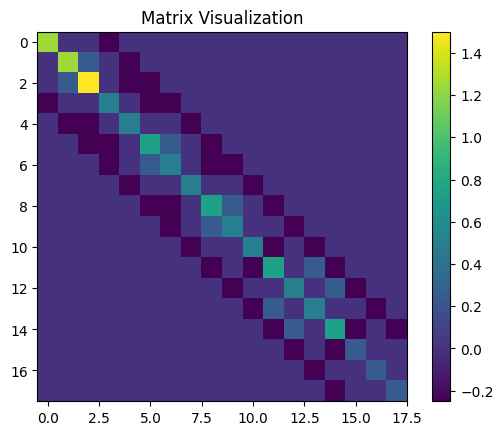

9.313225746154793e-10

In [6]:
graph = gtsam.NonlinearFactorGraph()
poses = gtsam.Values()

PRIOR_NOISE = gtsam.noiseModel.Diagonal.Sigmas(1 * np.array([1.0, 1.0, 1.0]))
ODOMETRY_NOISE = gtsam.noiseModel.Diagonal.Sigmas(2 * np.array([1.0, 1.0, 1.0]))

pose = gtsam.Pose2(np.zeros(3))
graph.add(gtsam.PriorFactorPose2(0, pose, PRIOR_NOISE))
poses.insert(0, pose)

graph.add(gtsam.BetweenFactorPose2(0, 1, gtsam.Pose2(1, 0, 0), ODOMETRY_NOISE))
poses.insert(1, gtsam.Pose2(1, 0, 0))

graph.add(gtsam.BetweenFactorPose2(1, 2, gtsam.Pose2(0, 1, 0), ODOMETRY_NOISE))
poses.insert(2, gtsam.Pose2())

graph.add(gtsam.BetweenFactorPose2(2, 3, gtsam.Pose2(0, 1, 0), ODOMETRY_NOISE))
poses.insert(3, gtsam.Pose2())

graph.add(gtsam.BetweenFactorPose2(3, 4, gtsam.Pose2(-1, 0, 0), ODOMETRY_NOISE))
poses.insert(4, gtsam.Pose2())

graph.add(gtsam.BetweenFactorPose2(4, 5, gtsam.Pose2(0, -1, 0), ODOMETRY_NOISE))
poses.insert(5, gtsam.Pose2())

# graph.add(gtsam.BetweenFactorPose2(5, 0, gtsam.Pose2(0, -1, 0), ODOMETRY_NOISE))

optimizer = gtsam.LevenbergMarquardtOptimizer(graph, poses)
poses = optimizer.optimize()

print(poses)

H = graph.linearize(poses).hessian()[0]

plt.imshow(H, cmap='viridis', interpolation='nearest')
plt.colorbar()  # Add a color bar to the side
plt.title('Matrix Visualization')
plt.show()

H

np.linalg.det(H)

Values with 6 values:
Value 0: (gtsam::Pose2)
(-4.59851e-10, -1.40943e-09, -1.37447e-11)

Value 1: (gtsam::Pose2)
(1, -7.48588e-10, -1.87738e-10)

Value 2: (gtsam::Pose2)
(1, 1, 1.72296e-10)

Value 3: (gtsam::Pose2)
(1, 2, 1.57825e-09)

Value 4: (gtsam::Pose2)
(-1.26916e-08, 2, 3.32242e-09)

Value 5: (gtsam::Pose2)
(-5.62232e-09, 1, 2.8433e-09)




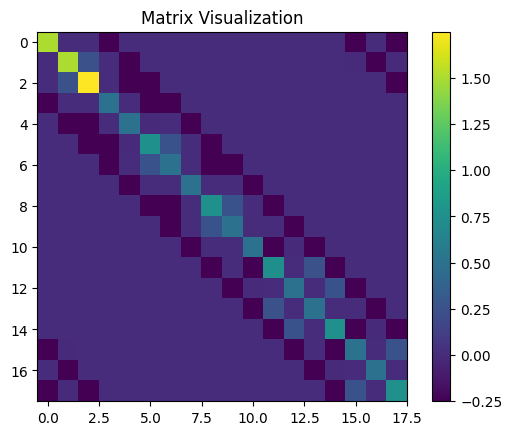

4.1909515703771165e-07

In [7]:
graph = gtsam.NonlinearFactorGraph()
poses = gtsam.Values()

PRIOR_NOISE = gtsam.noiseModel.Diagonal.Sigmas(1 * np.array([1.0, 1.0, 1.0]))
ODOMETRY_NOISE = gtsam.noiseModel.Diagonal.Sigmas(2 * np.array([1.0, 1.0, 1.0]))

pose = gtsam.Pose2(np.zeros(3))
graph.add(gtsam.PriorFactorPose2(0, pose, PRIOR_NOISE))
poses.insert(0, pose)

graph.add(gtsam.BetweenFactorPose2(0, 1, gtsam.Pose2(1, 0, 0), ODOMETRY_NOISE))
poses.insert(1, gtsam.Pose2(1, 0, 0))

graph.add(gtsam.BetweenFactorPose2(1, 2, gtsam.Pose2(0, 1, 0), ODOMETRY_NOISE))
poses.insert(2, gtsam.Pose2())

graph.add(gtsam.BetweenFactorPose2(2, 3, gtsam.Pose2(0, 1, 0), ODOMETRY_NOISE))
poses.insert(3, gtsam.Pose2())

graph.add(gtsam.BetweenFactorPose2(3, 4, gtsam.Pose2(-1, 0, 0), ODOMETRY_NOISE))
poses.insert(4, gtsam.Pose2())

graph.add(gtsam.BetweenFactorPose2(4, 5, gtsam.Pose2(0, -1, 0), ODOMETRY_NOISE))
poses.insert(5, gtsam.Pose2())

graph.add(gtsam.BetweenFactorPose2(5, 0, gtsam.Pose2(0, -1, 0), ODOMETRY_NOISE))

optimizer = gtsam.LevenbergMarquardtOptimizer(graph, poses)
poses = optimizer.optimize()

print(poses)

H = graph.linearize(poses).hessian()[0]

plt.imshow(H, cmap='viridis', interpolation='nearest')
plt.colorbar()  # Add a color bar to the side
plt.title('Matrix Visualization')
plt.show()

H

np.linalg.det(H)